# Computing second-order clustering correlation functions

In this notebook we compute the two-point correlation function of the galaxy overdensity field on a mock catalog and transform them to the second-order aperture statistics.

In [1]:
from astropy.table import Table
import numpy as np
from matplotlib import pyplot as plt

import orpheus

## Initialise the data catalog instance

For this exercise we use a simplistic mock catalog built from the [Takahasi simulation suite](http://cosmo.phys.hirosaki-u.ac.jp/takahasi/allsky_raytracing) that traces two tomographic bins in a _Euclid_-like setup for the $n(z)$ and uses a linear galaxy bias. 

Let us first load the data and then plot the redshift distribution of the two tomographic bins.

_Note: The funny names of the keys of the dict arise because we are using the same catalog for the computation of mixed correlators between positions and galaxy shapes._

In [2]:
catname = "data_g3l.npz"

In [3]:
mock = np.load(catname)

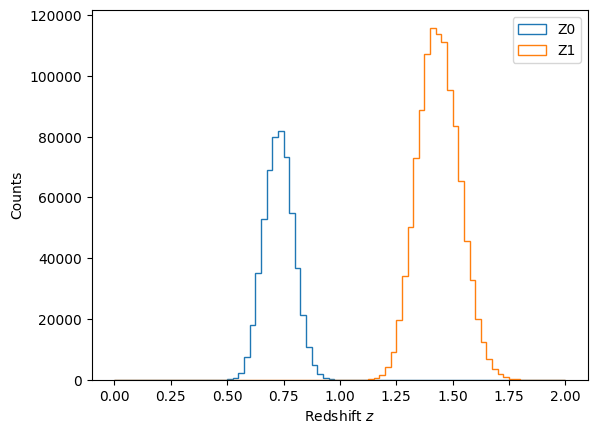

In [4]:
plt.hist(mock['z_lens_true'],bins=np.linspace(0,2,81),histtype='step',lw=3,label='Z0')
plt.hist(mock['z_source_true'],bins=np.linspace(0,2,81),histtype='step',lw=3,label='Z1')
plt.xlabel(r'Redshift $z$')
plt.ylabel('Counts')
plt.legend()
plt.show()

In order to not sample the galaxies to a realistic nbar, we subselect every tenth galaxy in each tomographic bin and then allocate a ``ScalarTracerCatalog`` instance with the concatenation of data within the two tomographic bins. 

In [5]:
fthin = 10

pos1_z1_thinned = mock["x_lens"][::fthin]
pos1_z2_thinned = mock["x_source"][::fthin]
pos2_z1_thinned = mock["y_lens"][::fthin]
pos2_z2_thinned = mock["y_source"][::fthin]

In [6]:
zbins = np.zeros(len(pos1_z1_thinned)+len(pos1_z2_thinned),dtype=int)
zbins[len(pos1_z1_thinned):] = 1
data = orpheus.ScalarTracerCatalog(pos1=np.append(pos1_z1_thinned, pos1_z2_thinned), 
                                   pos2=np.append(pos2_z1_thinned, pos2_z2_thinned), 
                                   tracer=np.ones(len(pos1_z1_thinned)+len(pos1_z2_thinned)), 
                                   zbins=zbins)

## Initialise the random catalog instance

Given the simple nature on how the mock data was created (i.e. there is just a binary mask with no further radial or angular selection) we can quite easily construct a random catalog ourselves. To do this we first estimate the angular mask of the catalog using the ``create_mask`` method of the ``ScalarCatalog`` instance and from infer $\overline{n}_{\mathrm{data}}$. In a second step, we use the ``orpheus``-internal ``FlatDataGrid_2D.samplePoints`` method on the instance of ``FlatDataGrid_2D``to poisson-sample points within the interior of the mask _(note that this class was initialised when estimating the mask of the catalog)_.

In [7]:
# Estimate the nbar of the data catalog using an estimate of the footprint area via the inferred mask
data.create_mask(method='Density', pixsize=5.)
footprint_area = np.sum(data.mask.data==0)*data.mask.dpix_1*data.mask.dpix_2
nbar = data.ngal/footprint_area

# Assuming a solely angular selection function for the data, we can quickly get a random catalog 
# by Poisson sampling points within the interior of the inferred mask.
# To ensure reproducibility we fix a random state for the creation of the random catalog.
rng_randcat = np.random.RandomState(seed=42)
rand_1, rand_2 = data.mask.samplePoints(nbar=100*nbar, method='Poisson', rng=rng_randcat)

print(nbar)

0.44354151260504204


We can now initialise the random catalog instance the same way as we did for the data one.

In [8]:
# Define tomographic bins for the random catalog s.t. the number density ratio is constant across tomographic bins
nrand_z1 = int(np.sum(data.zbins==0)/data.ngal*len(rand_1))
zbins_rand = np.zeros(len(rand_1), dtype=int)
zbins_rand[nrand_z1:] = 1

# Allocate the random catalog as an orpheus instance
randoms = orpheus.ScalarTracerCatalog(pos1=rand_1, pos2=rand_2, tracer=np.ones_like(rand_1), zbins=zbins_rand)

As a sanity check let's overlay the inferred mask with the (thinned) data and randoms distribution.

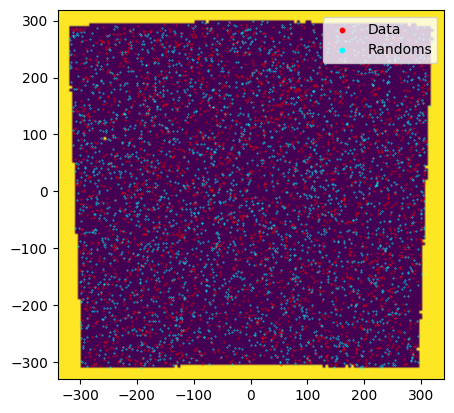

In [9]:
plt.imshow(data.mask.data, origin='lower',
           extent=[data.mask.pix1_lbounds[0], data.mask.pix1_lbounds[-1]+data.mask.dpix_1,
                   data.mask.pix2_lbounds[0], data.mask.pix2_lbounds[-1]+data.mask.dpix_2])
plt.scatter(data.pos1[data.zbins==0][::20], data.pos2[data.zbins==0][::20],s=0.1,color='red',label='Data')
plt.scatter(randoms.pos1[randoms.zbins==0][::2000], randoms.pos2[randoms.zbins==0][::2000],s=0.1,color='cyan',label='Randoms')
plt.legend(loc="upper right", markerscale=10)
plt.show()

## Computation of the second-order clustering correlation function

For computing the clustering correlation function we need to invoke the `NNCorrelation` class. In principle, it is only required to define a binning for the 2pcf (given by the range of the bins and the number of bins).

**Notes**

* Instead of the number of bins you can also specify the logarithmic bin-width `binsize`. However, the final value of `binsize` might differ slightly from the provided one as we fix the values for the binning range and then choose the largest possible value of `binsize` that is smaller or equal to the input value for `binsize`.

* If no further parameters are passed, the default setup chooses some accelerations of the DoubleTree estimator which renders fairly accurate results for the 2pcf itself and percent-level accuracy for the aperture statistics. In case you want a different setup than the default results you can change the parameters of the parent `BinnedNPCF` class.

* In contrast to the other NPCFs we place the tracers of the reduced catalogs not at the center-of-mass, but apply a random shift within the cell. I found that this greatly speeds up convergence (i.e. one can choose a fairly small ``rmin_pixsize``) using simple selection functions as presented here.
**TODO: Could this become problematic in case of a highly variable selection function? How realistic is such a case?**

In [10]:
min_sep = 0.125
max_sep = 256.
verbosity = 2
binsize=0.1
tree_resos = [0., 0.25, 0.5, 1., 2.]
rmin_pixsize = 10
nthreads = 48

In [11]:
nncorr = orpheus.NNCorrelation(min_sep=min_sep,max_sep=max_sep,binsize=binsize, 
                               tree_resos=tree_resos, rmin_pixsize=rmin_pixsize, 
                               verbosity=verbosity, nthreads=nthreads)

Let us now compute the correlation function. For this we use the ``process`` method and we explictly pass the random catalog instance which triggers a computation of all (tomographic) dd/dr/rd/rr-paircounts, as well as their combination to xi using the Landy-Szalay estimator.

_Note: Under the hood, this setup calls the private ``__compute_xi`` method. Be aware that upon calling the ``__compute_xi`` method, the pair-count attributes of the instance will have a different shape as xi. This is because they contain all dd/dr/rd/rr-combinations -- see the documentation within the ``__compute_xi``-method for further details._

In [12]:
%%time
nncorr.process(cat=data, cat_random=randoms)

.........................................................................................................
CPU times: user 25min 49s, sys: 4.93 s, total: 25min 54s
Wall time: 50 s


Let us now plot the resulting 2pcfs. We can interpret the result as follows:
* For the auto-tomographic correlations we see a stronger signal for the lower redshift bin. This is expected as we expect a stronger clustering at later times and this observation is not conceptually modified by the linear galaxy bias.
* For the cross-tomographic correlations we observe that both give the same value and that they are consistent with zero. Again, the first observation should be fulfilled by construction while the second one arises as the tomographic bins are quite significantly separated in redshift.
* For very small distances the correlation appears to be negative. This is not what I would expect. However, these scales are pretty small and are roughly of the pixel-size of the original overdensity field, so maybe those are pixel-related effects? Repeathing the 2pcf computation with treecorr _(using bin_slop = 0.1 to get a similarly small variance)_ I find the same behaviour, so this is most likely not due to the measurement code.

Text(0, 0.5, '$\\theta \\ \\xi(\\theta)$')

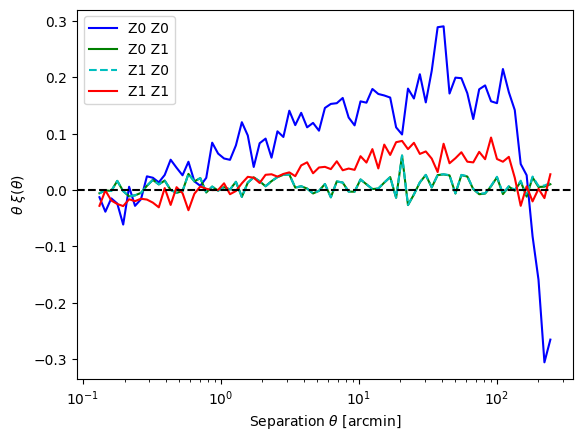

In [13]:
plt.semilogx(nncorr.bin_centers_mean, nncorr.bin_centers_mean*nncorr.xi[0], 'b-', label='Z0 Z0')
plt.semilogx(nncorr.bin_centers_mean, nncorr.bin_centers_mean*nncorr.xi[1], 'g-', label='Z0 Z1')
plt.semilogx(nncorr.bin_centers_mean, nncorr.bin_centers_mean*nncorr.xi[2], 'c--', label='Z1 Z0')
plt.semilogx(nncorr.bin_centers_mean, nncorr.bin_centers_mean*nncorr.xi[3], 'r-', label='Z1 Z1')
plt.axhline(0,color='k',ls='--')
plt.legend()
plt.xlabel(r'Separation $\theta$ [arcmin]')
plt.ylabel(r"$\theta \ \xi(\theta)$")

## Computation of the aperture statistics

The integral transormation between the density 2PCF and their second-order aperture counts statistics can be done by calling the `NNCorrelatoin.computeNap2` method.

**Notes**

* In case you are only interested in obtaining the third-order aperture statistics, you can also directly call this method right after processing the shape catalog.

* One should only trust the third-order aperture statistics for radii $R\in[\alpha\,\theta_{\rm min}, \beta\,\theta_{\rm max}]$, where $\alpha\approx 5$  and $\beta \approx 0.125$. In the plot below this range is indicated by the dashed vertical lines.

* Furthermore, the binning should be sufficiently fine, i.e. the value of the `GNNCorrelation.binsize` attribute should be less than `0.1` for an accuracy of about one per cent.

In [14]:
%%time
radii_ap = np.geomspace(1.,64.,24)
Nap2 = nncorr.computeNap2(radii_ap)

CPU times: user 2.79 ms, sys: 989 µs, total: 3.77 ms
Wall time: 3.68 ms


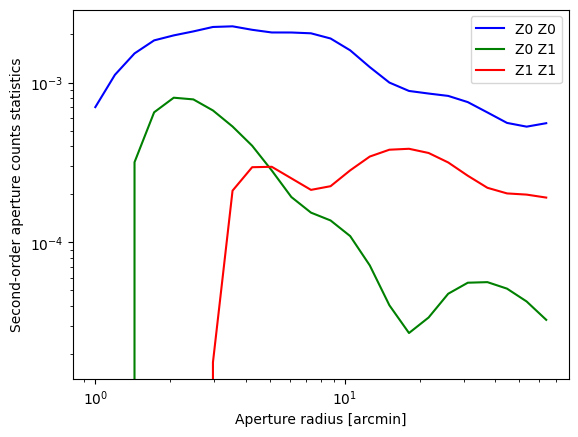

In [15]:
plt.loglog(radii_ap, Nap2[0], 'b-', label="Z0 Z0")
plt.loglog(radii_ap, Nap2[1], 'g-', label="Z0 Z1")
plt.loglog(radii_ap, Nap2[3], 'r-', label="Z1 Z1")

plt.xlabel("Aperture radius [arcmin]")
plt.ylabel("Second-order aperture counts statistics")
plt.legend(loc="upper right")
#plt.ylim(1e-8,None)

In [17]:
# As we will need this result for mixed correlators of shapes and positions, we save this result.
nncorr.saveinst(path_save="", fname="nncorr")